# PyTorch Basics: A Hands-On Introduction

This notebook provides a practical introduction to PyTorch, covering essential concepts such as tensors, basic operations, automatic differentiation, and simple neural network construction. Each section includes code examples and explanations to help you get started with deep learning using PyTorch.

## Introduction to PyTorch

PyTorch is a popular open-source deep learning framework that provides flexibility and speed when building machine learning models. In this notebook, we will explore the basics of PyTorch, including tensor operations, automatic differentiation, and simple neural network construction.

In [3]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt
import matplotlib
# !pip install drawnow  # Uncomment if drawnow is not installed
from drawnow import drawnow
import numpy as np


### 1. Importing PyTorch and Basic Setup

Let's start by importing PyTorch and checking the version. This ensures that the library is installed and ready to use.

In [4]:
# Check if all imports are working
try:
    # Check if torch is working and the available backend
    if torch.cuda.is_available():
        backend = "CUDA"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        backend = "MPS (Metal Performance Shaders, available on Apple MacBook Pros)"
    else:
        backend = "CPU"
    print(f"Torch is working, using {backend} backend.")

    # Test other imports
    try:
        _ = nn.Linear(10, 5)  # Test torch.nn
        _ = torchvision.models.resnet18()  # Test torchvision.models
        _ = DataLoader([])  # Test torch.utils.data
        _ = datasets.FakeData(transform=ToTensor())  # Test torchvision.datasets and transforms
        _ = Compose([ToTensor(), Lambda(lambda x: x)])  # Test torchvision.transforms.Compose and Lambda
        fig, ax = plt.subplots()  # Test matplotlib.pyplot
        ax.plot([0, 1], [0, 1])
        plt.close(fig)  # Close the figure after testing
        print("All imports are working correctly.")
    except Exception as e:
        print(f"An error occurred while testing imports: {e}")
except Exception as e:
    print(f"An error occurred: {e}")


Torch is working, using MPS (Metal Performance Shaders, available on Apple MacBook Pros) backend.
All imports are working correctly.


In [5]:
# Print Version Info
print(f"-------------------- Version Info --------------------")
print(f"Torch       = {torch.__version__}")
print(f"TorchVision = {torchvision.__version__}")
print(f"Matplotlib  = {matplotlib.__version__}")
print(f"Numpy       = {np.__version__}")
print(f"------------------------------------------------------")

-------------------- Version Info --------------------
Torch       = 2.8.0
TorchVision = 0.23.0
Matplotlib  = 3.9.4
Numpy       = 2.0.2
------------------------------------------------------


### 2. Tensor Creation and Basic Operations

PyTorch tensors are similar to NumPy arrays but can run on GPUs. Here, we create tensors and perform basic operations to understand their behavior.

In [6]:
# Demonstrating comprehensive tensor operations
a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5, 6])
random_tensor = torch.rand(3, 3)
tensor_from_list = torch.tensor([1, 2, 3, 4, 5])
import torch.nn.functional as F

print("------ Input Tensors ------")
print("Tensor A:", a)
print("Tensor B:", b)
print("Random Tensor:\n", random_tensor)
print("Tensor from List:\n", tensor_from_list, "\n")
print("---------------------------\n")

print("1. Basic and Advanced Arithmetic:")
print("Element-wise product:", torch.mul(a, b))
print("Power operation:", torch.pow(a, 2))
print("Matrix product:", torch.matmul(random_tensor, random_tensor))

print("\n2. Advanced Matrix Operations:")
eigenvalues = torch.linalg.eigvals(random_tensor)
print("Eigenvalues:", eigenvalues)
print("Determinant:", torch.linalg.det(random_tensor))
print("Matrix inverse:", torch.linalg.inv(random_tensor))

print("\n3. Advanced Statistical Operations:")
print("Standard deviation:", random_tensor.std())
print("Variance:", random_tensor.var())
print("Cumulative sum:", torch.cumsum(tensor_from_list, 0))

print("\n4. Tensor Transformations:")
tensor_from_list_float = tensor_from_list.to(torch.float32)
print("Softmax:", F.softmax(tensor_from_list_float, dim=0))
print("Log softmax:", F.log_softmax(tensor_from_list_float, dim=0))

print("\n5. Advanced Indexing:")
mask = random_tensor > 0.5
print("Boolean masking:", random_tensor[mask])
print("Top-2 values:", torch.topk(random_tensor.flatten(), 2))

print("\n6. Tensor Statistics:")
print("Is any value NaN?:", torch.isnan(random_tensor).any())
print("Correlation matrix:\n", torch.corrcoef(random_tensor))

------ Input Tensors ------
Tensor A: tensor([1, 2, 3])
Tensor B: tensor([4, 5, 6])
Random Tensor:
 tensor([[0.3572, 0.8224, 0.2880],
        [0.0560, 0.8043, 0.9610],
        [0.9859, 0.9801, 0.5179]])
Tensor from List:
 tensor([1, 2, 3, 4, 5]) 

---------------------------

1. Basic and Advanced Arithmetic:
Element-wise product: tensor([ 4, 10, 18])
Power operation: tensor([1, 4, 9])
Matrix product: tensor([[0.4576, 1.2375, 1.0425],
        [1.0125, 1.6348, 1.2868],
        [0.9176, 2.1067, 1.4941]])

2. Advanced Matrix Operations:
Eigenvalues: tensor([-0.1434+0.4001j, -0.1434-0.4001j,  1.9661+0.0000j])
Determinant: tensor(0.3551)
Matrix inverse: tensor([[-1.4794, -0.4045,  1.5733],
        [ 2.5862, -0.2786, -0.9212],
        [-2.0781,  1.2973,  0.6793]])

3. Advanced Statistical Operations:
Standard deviation: tensor(0.3461)
Variance: tensor(0.1198)
Cumulative sum: tensor([ 1,  3,  6, 10, 15])

4. Tensor Transformations:
Softmax: tensor([0.0117, 0.0317, 0.0861, 0.2341, 0.6364])
Log

### 3. Tensor Operations and Manipulation

This section demonstrates how to manipulate tensors, including reshaping, slicing, and performing mathematical operations.

In [7]:
# Example 1: Creating a tensor from a list
tensor_from_list = torch.tensor([1, 2, 3, 4, 5])
print("Tensor from list:", tensor_from_list)

# Example 2: Creating a tensor with random values
random_tensor = torch.rand((3, 3))
print("Random tensor:\n", random_tensor)

# Example 3: Performing basic operations
a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5, 6])
sum_tensor = a + b
print("Sum of tensors:", sum_tensor)

# Example 4: Reshaping a tensor
reshaped_tensor = random_tensor.view(1, 9)
print("Reshaped tensor:\n", reshaped_tensor)

# Example 5: Moving a tensor to GPU (if available)
if torch.cuda.is_available():
    gpu_tensor = tensor_from_list.to('cuda')
    print("Tensor moved to GPU (CUDA):", gpu_tensor)
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    mps_tensor = tensor_from_list.to('mps')
    print("Tensor moved to GPU (MPS):", mps_tensor)
else:
    print("Neither CUDA nor MPS is available. Tensor remains on CPU.")

Tensor from list: tensor([1, 2, 3, 4, 5])
Random tensor:
 tensor([[0.0109, 0.5338, 0.3843],
        [0.0341, 0.8331, 0.3175],
        [0.2696, 0.7414, 0.1883]])
Sum of tensors: tensor([5, 7, 9])
Reshaped tensor:
 tensor([[0.0109, 0.5338, 0.3843, 0.0341, 0.8331, 0.3175, 0.2696, 0.7414, 0.1883]])
Tensor moved to GPU (MPS): tensor([1, 2, 3, 4, 5], device='mps:0')


### 4. CUDA Tensors and GPU Operations

PyTorch makes it easy to move tensors between CPU and GPU. This section shows how to check for GPU availability and perform operations on CUDA tensors.

In [8]:
# Example 1: Check device availability and capabilities
print("=== Device Information ===")
if torch.cuda.is_available():
    print(f"CUDA available: {torch.cuda.is_available()}")
    print(f"CUDA device count: {torch.cuda.device_count()}")
    print(f"Current CUDA device: {torch.cuda.current_device()}")
    print(f"Device name: {torch.cuda.get_device_name()}")
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    print(f"MPS available: {torch.backends.mps.is_available()}")
    print("Using Metal Performance Shaders (Apple Silicon)")
    device = torch.device('mps')
else:
    print("Using CPU for computations")
    device = torch.device('cpu')
print()

# Example 2: Create tensors on different devices
print("=== Tensor Device Operations ===")
# Create tensor on CPU
cpu_tensor = torch.randn(3, 3)
print(f"CPU tensor device: {cpu_tensor.device}")
print(f"CPU tensor:\n{cpu_tensor}")

# Move tensor to available device
tensor_on_device = cpu_tensor.to(device)
if device.type == 'cuda':
    print(f"\nGPU tensor device: {tensor_on_device.device}")
    print(f"GPU tensor:\n{tensor_on_device}")
elif device.type == 'mps':
    print(f"\nMPS tensor device: {tensor_on_device.device}")
    print(f"MPS tensor:\n{tensor_on_device}")
else:
    print(f"\nTensor remains on CPU: {tensor_on_device.device}")

# Example 3: Perform operations on device tensors
print("\n=== Device Operations ===")
# Create tensors directly on device
device_tensor1 = torch.randn(2, 2, device=device)
device_tensor2 = torch.randn(2, 2, device=device)

print(f"Device tensor 1:\n{device_tensor1}")
print(f"Device tensor 2:\n{device_tensor2}")

# Perform operations on device
device_sum = device_tensor1 + device_tensor2
device_product = torch.matmul(device_tensor1, device_tensor2)
device_sqrt = torch.sqrt(torch.abs(device_tensor1))

print(f"\nSum on device:\n{device_sum}")
print(f"Matrix product on device:\n{device_product}")
print(f"Square root on device:\n{device_sqrt}")

# Example 4: Move results back to CPU for display
print("\n=== Moving Back to CPU ===")
cpu_sum = device_sum.cpu()
cpu_product = device_product.cpu()
cpu_sqrt = device_sqrt.cpu()

print(f"Sum moved to CPU:\n{cpu_sum}")
print(f"Product moved to CPU:\n{cpu_product}")
print(f"Square root moved to CPU:\n{cpu_sqrt}")

# Example 5: Memory management and device synchronization
print("\n=== Memory Management ===")
if device.type == 'cuda':
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
    print(f"GPU memory cached: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")
    torch.cuda.empty_cache()
    print("GPU cache cleared")
elif device.type == 'mps':
    print("MPS memory management is handled automatically by the system")
else:
    print("CPU memory management is handled by the operating system")

=== Device Information ===
MPS available: True
Using Metal Performance Shaders (Apple Silicon)

=== Tensor Device Operations ===
CPU tensor device: cpu
CPU tensor:
tensor([[-1.0973,  1.0162, -0.9045],
        [ 0.3647,  1.0426,  0.0843],
        [ 0.4692, -0.8148, -1.7887]])

MPS tensor device: mps:0
MPS tensor:
tensor([[-1.0973,  1.0162, -0.9045],
        [ 0.3647,  1.0426,  0.0843],
        [ 0.4692, -0.8148, -1.7887]], device='mps:0')

=== Device Operations ===
Device tensor 1:
tensor([[ 0.2344, -0.5436],
        [-0.6658, -0.1052]], device='mps:0')
Device tensor 2:
tensor([[-0.0502, -0.8509],
        [ 1.8139,  0.1239]], device='mps:0')

Sum on device:
tensor([[ 0.1842, -1.3945],
        [ 1.1481,  0.0187]], device='mps:0')
Matrix product on device:
tensor([[-0.9978, -0.2669],
        [-0.1574,  0.5535]], device='mps:0')
Square root on device:
tensor([[0.4842, 0.7373],
        [0.8160, 0.3244]], device='mps:0')

=== Moving Back to CPU ===
Sum moved to CPU:
tensor([[ 0.1842, -1.3945

### 5. Automatic Differentiation with Autograd

PyTorch's autograd system automatically computes gradients for tensor operations. This section demonstrates how to use autograd for gradient computation.

In [9]:
# Example 1: Basic gradient computation
print("=== Basic Gradient Computation ===")
x = torch.tensor([2.0], requires_grad=True)
print(f"Input tensor x: {x}")
print(f"x.requires_grad: {x.requires_grad}")
y = x**2 + 3*x + 1
print(f"Function y = x^2 + 3x + 1: {y}")
print(f"y.requires_grad: {y.requires_grad}")
y.backward()
print(f"Gradient dy/dx: {x.grad}")
print(f"Expected gradient (2x + 3 at x=2): {2*2 + 3}")
print()

# Example 2: Gradients with multiple variables
print("=== Multiple Variables ===")
a = torch.tensor([3.0], requires_grad=True)
b = torch.tensor([4.0], requires_grad=True)
print(f"Input tensors a: {a}, b: {b}")
z = a**2 + b**3 + a*b
print(f"Function z = a^2 + b^3 + a*b: {z}")
z.backward()
print(f"Gradient dz/da: {a.grad}")
print(f"Gradient dz/db: {b.grad}")
print(f"Expected dz/da (2a + b at a=3, b=4): {2*3 + 4}")
print(f"Expected dz/db (3b^2 + a at a=3, b=4): {3*4**2 + 3}")
print()

# Example 3: Chain rule demonstration
print("=== Chain Rule Demonstration ===")
x = torch.tensor([1.0], requires_grad=True)
u = x**2
v = u + 1
w = v**2
print(f"x: {x.item():.4f}")
print(f"u = x^2: {u.item():.4f}")
print(f"v = u + 1: {v.item():.4f}")
print(f"w = v^2: {w.item():.4f}")
w.backward()
print(f"dw/dx: {x.grad.item():.4f}")
print(f"Expected dw/dx (4x(x^2 + 1) at x=1): {4*1*(1**2 + 1):.4f}")
print()

# Example 4: Working with vector functions
print("=== Vector Functions ===")
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
print(f"Input vector x: {x}")
y = torch.sum(x**2)
print(f"Scalar output y = sum(x^2): {y}")
y.backward()
print(f"Gradient dy/dx: {x.grad}")
print(f"Expected gradients [2x1, 2x2, 2x3]: {2*x.data}")
print()

# Example 5: Matrix operations with gradients
print("=== Matrix Operations ===")
A = torch.randn(2, 2, requires_grad=True)
B = torch.randn(2, 2, requires_grad=True)
print(f"Matrix A:\n{A}")
print(f"Matrix B:\n{B}")
C = torch.matmul(A, B)
scalar_output = torch.sum(C)
print(f"Scalar output (sum of A @ B): {scalar_output}")
scalar_output.backward()
print(f"Gradient w.r.t. A:\n{A.grad}")
print(f"Gradient w.r.t. B:\n{B.grad}")
print()

# Example 6: Gradient accumulation and zeroing
print("=== Gradient Accumulation ===")
x = torch.tensor([2.0], requires_grad=True)
y1 = x**2
y1.backward()
print(f"After first backward (y1 = x^2): x.grad = {x.grad}")
y2 = x**3
y2.backward()
print(f"After second backward (y2 = x^3): x.grad = {x.grad} (accumulated)")
x.grad.zero_()
y3 = x**4
y3.backward()
print(f"After zeroing and third backward (y3 = x^4): x.grad = {x.grad}")
print()

# Example 7: Detaching from computation graph
print("=== Detaching from Computation Graph ===")
x = torch.tensor([3.0], requires_grad=True)
y = x**2
z = y.detach()
w = z**2
print(f"x: {x}, y: {y}, z: {z}, w: {w}")
print(f"z.requires_grad: {z.requires_grad}")
print(f"w.requires_grad: {w.requires_grad}")
y.backward()
print(f"After y.backward(), x.grad: {x.grad}")

=== Basic Gradient Computation ===
Input tensor x: tensor([2.], requires_grad=True)
x.requires_grad: True
Function y = x^2 + 3x + 1: tensor([11.], grad_fn=<AddBackward0>)
y.requires_grad: True
Gradient dy/dx: tensor([7.])
Expected gradient (2x + 3 at x=2): 7

=== Multiple Variables ===
Input tensors a: tensor([3.], requires_grad=True), b: tensor([4.], requires_grad=True)
Function z = a^2 + b^3 + a*b: tensor([85.], grad_fn=<AddBackward0>)
Gradient dz/da: tensor([10.])
Gradient dz/db: tensor([51.])
Expected dz/da (2a + b at a=3, b=4): 10
Expected dz/db (3b^2 + a at a=3, b=4): 51

=== Chain Rule Demonstration ===
x: 1.0000
u = x^2: 1.0000
v = u + 1: 2.0000
w = v^2: 4.0000
dw/dx: 8.0000
Expected dw/dx (4x(x^2 + 1) at x=1): 8.0000

=== Vector Functions ===
Input vector x: tensor([1., 2., 3.], requires_grad=True)
Scalar output y = sum(x^2): 14.0
Gradient dy/dx: tensor([2., 4., 6.])
Expected gradients [2x1, 2x2, 2x3]: tensor([2., 4., 6.])

=== Matrix Operations ===
Matrix A:
tensor([[ 0.7881,

### 6. Building a Simple Neural Network

#### - Data and Dataloading
Let's start by downloading the data and creating Training and Test datasets. Subsequently, we will load the relevant data using `DataLoader` and verify by checking the shape and type of the data.

In [10]:
# Download training and test data from open datasets.
from torchvision import transforms

# Mean and std for FashionMNIST (precomputed)
FASHION_MNIST_MEAN = 0.2860406
FASHION_MNIST_STD = 0.35302424

# Use only light augmentation for training data, then normalize
train_transforms = transforms.Compose([
    transforms.RandomCrop(28, padding=2),
    transforms.RandomRotation(10),    
    transforms.ToTensor(),
    transforms.Normalize((FASHION_MNIST_MEAN,), (FASHION_MNIST_STD,))
])

# For test data, only convert to tensor and normalize (no augmentation)
test_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((FASHION_MNIST_MEAN,), (FASHION_MNIST_STD,))
])

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=train_transforms,
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=test_transforms,
)

batch_size = 128
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for data, target in test_dataloader:
    print(f"Shape of Data [N, C, H, W] : {data.shape} \nDType : {data.dtype}")
    print(f"\nShape of target : {target.shape} \nDType : {target.dtype}  ")
    break
print("------------------------------------------------------")


Shape of Data [N, C, H, W] : torch.Size([128, 1, 28, 28]) 
DType : torch.float32

Shape of target : torch.Size([128]) 
DType : torch.int64  
------------------------------------------------------


#### - Building the actual Neural Network
This section covers how to define and use a simple neural network in PyTorch using the `nn.Module` class.

In [11]:
# Optimized model for FashionMNIST classification
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Use a more efficient architecture with fewer parameters and Dropout for regularization
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28*28, 256),      # Reduce input layer size for efficiency
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(64, 10)           # Output layer: 64 -> 10 (number of classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)

class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # [B, 32, 28, 28]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                             # [B, 32, 14, 14]

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # [B, 64, 14, 14]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                             # [B, 64, 7, 7]
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("Device = ", device, "\n")
model = FashionCNN().to(device)
print(model)


Device =  mps 

FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


### 7. Loss Functions and Optimizers

PyTorch provides various loss functions and optimizers. This section demonstrates how to use them for training neural networks.

In [12]:

# SOTA (State-of-the-Art) combination for classification on FashionMNIST

learning_rate = 2e-4  # Lower learning rate for AdamW
weight_decay = 1e-2   # Stronger regularization for generalization

# Use label smoothing for better calibration and generalization
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.0)

# AdamW is SOTA for most vision tasks
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay, betas=(0.9, 0.999), eps=1e-8)

# Cosine Annealing with Warm Restarts is SOTA for learning rate scheduling
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-6)


### 8. Training the Neural Network

This section demonstrates how to train the neural network using the defined loss function and optimizer, and how to monitor the training process.

In [13]:
def train(dataloader, model, loss_fn, optimizer, grad_clip=1.0, gradient_norms=[]):
    """
    Trains the model for one epoch.

    Args:
        dataloader: DataLoader providing batches of (data, target).
        model: The neural network model to train.
        loss_fn: Loss function to optimize.
        optimizer: Optimizer for updating model parameters.
        grad_clip: Maximum norm for gradient clipping (default 1.0).

    Returns:
        avg_loss: Average loss over the epoch.
        accuracy: Accuracy over the epoch.
    """
    model.train()  # Set model to training mode
    running_loss = 0.0  # Accumulate total loss
    correct = 0         # Count of correct predictions
    total = 0           # Total number of samples

    for batch_idx, (data, target) in enumerate(dataloader):
        # Move data and target to the appropriate device (CPU or GPU)
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()  # Zero the parameter gradients

        output = model(data)   # Forward pass
        loss = loss_fn(output, target)  # Compute loss

        loss.backward()  # Backward pass (compute gradients)
        
        total_norm = 0.0
        for p in model.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        total_norm = total_norm ** 0.5
        gradient_norms.append(total_norm)

        # Clip gradients to avoid exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()  # Update model parameters

        # Accumulate loss (multiply by batch size to get total loss)
        batch_size = data.size(0)
        running_loss += loss.item() * batch_size

        # Get predicted class by taking the argmax
        pred = output.argmax(dim=1)

        # Count correct predictions
        correct += (pred == target).sum().item()
        total += data.size(0)  # Update total number of samples


    # Compute average loss and accuracy for the epoch
    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

def test(dataloader, model, loss_fn, device=None):
    """
    Evaluate the model on the given dataloader.

    Args:
        dataloader: DataLoader for the test/validation set.
        model: The neural network model to evaluate.
        loss_fn: Loss function to use.
        device: Device to run evaluation on (CPU or GPU). If None, uses model's device.

    Returns:
        avg_loss: Average loss over the dataset.
        accuracy: Accuracy over the dataset.
    """
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    # Infer device if not provided
    if device is None:
        try:
            device = next(model.parameters()).device
        except StopIteration:
            device = torch.device("cpu")

    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = loss_fn(output, target)
            test_loss += loss.item() * data.size(0)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += data.size(0)

    avg_loss = test_loss / total if total > 0 else 0.0
    accuracy = correct / total if total > 0 else 0.0
    return avg_loss, accuracy

class EarlyStopping:
    """
    Early stops the training if validation loss doesn't improve after a given patience.
    Also saves the model checkpoint when a new best is found.
    """
    def __init__(self, patience=10, min_delta=0.0, mode='min', verbose=False, checkpoint_path=None):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
            min_delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            mode (str): 'min' for loss, 'max' for accuracy/score.
            verbose (bool): If True, prints a message for each validation loss improvement.
            checkpoint_path (str or None): Path to save the best model weights. If None, does not save.
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_epoch = None
        self.checkpoint_path = checkpoint_path

        if self.mode == 'min':
            self.monitor_op = lambda current, best: current < best - self.min_delta
            self.best_score = float('inf')
        elif self.mode == 'max':
            self.monitor_op = lambda current, best: current > best + self.min_delta
            self.best_score = -float('inf')
        else:
            raise ValueError("mode must be 'min' or 'max'")

    def __call__(self, current, model=None, epoch=None):
        if self.monitor_op(current, self.best_score):
            self.best_score = current
            self.best_epoch = epoch
            self.counter = 0
            if self.verbose:
                print(f"EarlyStopping: New best score {self.best_score:.6f} at epoch {epoch}")
            if self.checkpoint_path is not None and model is not None:
                self.save_checkpoint(model)
        else:
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping: No improvement in monitored metric for {self.counter} epochs.")
            if self.counter >= self.patience:
                self.early_stop = True

    def save_checkpoint(self, model):
        """
        Saves model state_dict to the checkpoint path.
        """
        torch.save(model.state_dict(), self.checkpoint_path)
        if self.verbose:
            print(f"EarlyStopping: Model checkpoint saved to {self.checkpoint_path}")


### 9. Evaluating Model Performance

After training, it's important to evaluate the model's performance on test data. This section shows how to calculate accuracy and other metrics.

**Evaluation Metrics:**
- **Accuracy**: Percentage of correct predictions
- **Precision**: True positives / (True positives + False positives)
- **Recall**: True positives / (True positives + False negatives)
- **F1-Score**: Harmonic mean of precision and recall
- **Confusion Matrix**: Detailed breakdown of predictions vs. actual
- **ROC Curve**: Trade-off between true positive and false positive rates

**Evaluation Best Practices:**
- **Test Set**: Use held-out data not seen during training
- **Model Modes**: Always use `model.eval()` for evaluation
- **No Gradients**: Use `torch.no_grad()` to save memory
- **Batch Processing**: Evaluate in batches for efficiency
- **Multiple Runs**: Average results over multiple evaluations

,Epoch,Training Loss,Validation Loss,Training Accuracy,Validation Accuracy,Early Stopping Counter,Best Validation Loss
59,60,0.268285,0.223083,0.902467,0.9187,0,0.223083
60,61,0.267984,0.222321,0.903533,0.9193,0,0.222321
61,62,0.265064,0.223268,0.905500,0.9198,1,0.222321
62,63,0.265976,0.223001,0.903967,0.9188,2,0.222321
63,64,0.265077,0.222085,0.905417,0.9198,0,0.222085
64,65,0.265441,0.222939,0.905083,0.9203,1,0.222085
65,66,0.262009,0.222117,0.906217,0.9197,2,0.222085
66,67,0.261555,0.221641,0.906117,0.9200,0,0.221641
67,68,0.259121,0.221866,0.906600,0.9198,1,0.221641
68,69,0.261495,0.221470,0.905700,0.9192,0,0.221470


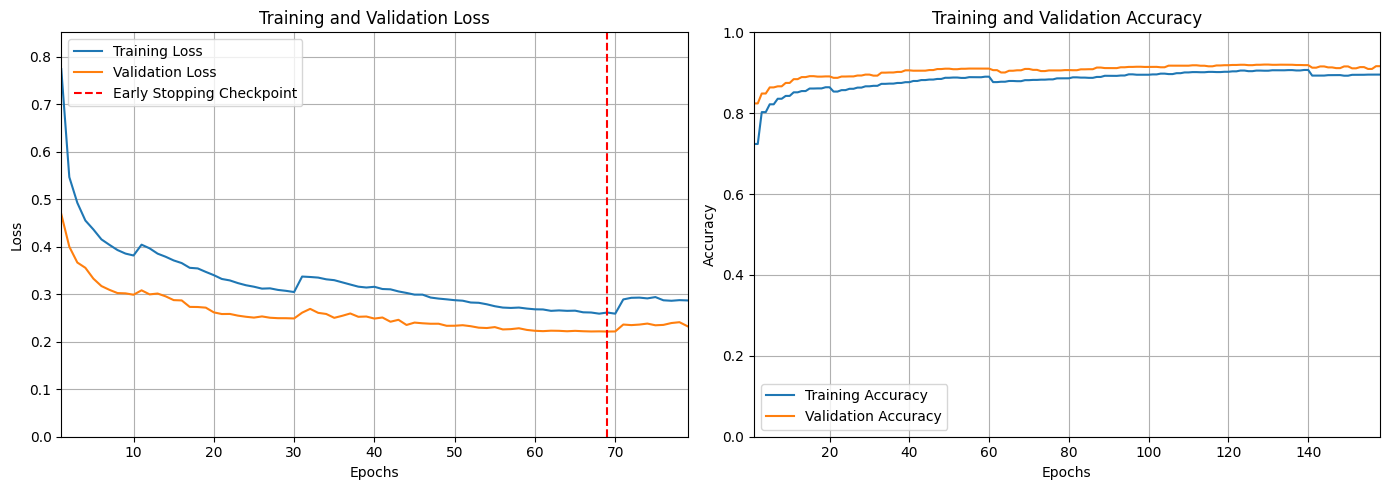

Epoch 79 stats:
  Avg Training Loss: 0.286975
  Avg Validation Loss: 0.232645
  Avg Training Accuracy: 0.8955
  Avg Validation Accuracy: 0.9163
  Early Stopping Counter: 10
  Best Validation Loss: 0.221470
----------------------------------------
Early stopping
Training completed in 13.76 min (825.7 sec)


In [14]:
import time
import pandas as pd
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

epochs = 200
patience = 10

stats_table = []
train_loss_history, val_loss_history = [], []
train_accuracy_history, val_accuracy_history = [], []  # Store accuracy per epoch

def plot_training_curves():
    """
    Efficiently plot loss and accuracy curves for training and validation, side by side.
    """
    # Use a single figure and axes, side by side
    fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

    # Plot 1: Losses (left)
    axs[0].set_title('Training and Validation Loss')
    if train_loss_history:
        axs[0].plot(range(1, len(train_loss_history) + 1), train_loss_history, label='Training Loss')
    if val_loss_history:
        axs[0].plot(range(1, len(val_loss_history) + 1), val_loss_history, label='Validation Loss')
        minpos = val_loss_history.index(min(val_loss_history)) + 1
        axs[0].axvline(minpos, linestyle='--', color='r', label='Early Stopping Checkpoint')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    if train_loss_history or val_loss_history:
        all_losses = []
        if train_loss_history:
            all_losses.extend(train_loss_history)
        if val_loss_history:
            all_losses.extend(val_loss_history)
        min_loss, max_loss = min(all_losses), max(all_losses)
        axs[0].set_ylim(min(0, min_loss * 0.9), max_loss * 1.1)
    else:
        axs[0].set_ylim(0, 1)
    axs[0].set_xlim(1, max(2, len(train_loss_history), len(val_loss_history), 2))
    axs[0].grid(True)
    axs[0].legend(loc='best')

    # Plot 2: Accuracies (right)
    axs[1].set_title('Training and Validation Accuracy')
    if train_accuracy_history:
        axs[1].plot(range(1, len(train_accuracy_history) + 1), train_accuracy_history, label='Training Accuracy')
    if val_accuracy_history:
        axs[1].plot(range(1, len(val_accuracy_history) + 1), val_accuracy_history, label='Validation Accuracy')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Accuracy')
    axs[1].set_ylim(0, 1)
    axs[1].set_xlim(1, max(2, len(train_accuracy_history), len(val_accuracy_history), 2))
    axs[1].grid(True)
    axs[1].legend(loc='best')

    plt.tight_layout()
    display(fig)
    plt.close(fig)


def update_stats_table(epoch, train_loss, val_loss, train_acc, val_acc, es_counter, es_best):
    stats_table.append({
        "Epoch": epoch,
        "Training Loss": train_loss,
        "Validation Loss": val_loss,
        "Training Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Early Stopping Counter": es_counter,
        "Best Validation Loss": es_best
    })
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    train_accuracy_history.append(train_acc)  # Store training accuracy
    val_accuracy_history.append(val_acc)      # Store validation accuracy
    df = pd.DataFrame(stats_table)
    clear_output(wait=True)
    display(df.tail(20))
    plot_training_curves()

early_stopper = EarlyStopping(
    patience=patience,
    verbose=True,
    checkpoint_path='checkpoint.pt'
)

start_time = time.time()
learning_rates = []
gradient_norms = []

for epoch in range(1, epochs+1):
    
    # Get current LR from the optimizer
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)
    
    train_loss, train_accuracy = train(
        dataloader=train_dataloader,
        model=model,
        loss_fn=loss_fn,
        optimizer=optimizer,
        grad_clip=1.0,
        gradient_norms=gradient_norms
    )
    val_loss, val_acc = test(
        dataloader=test_dataloader,
        model=model,
        loss_fn=loss_fn,
        device=device
    )
    # Store accuracy for this epoch
    train_accuracy_history.append(train_accuracy)
    val_accuracy_history.append(val_acc)
    if scheduler is not None:
        if hasattr(scheduler, 'step') and 'plateau' in scheduler.__class__.__name__.lower():
            scheduler.step(val_loss)
        else:
            scheduler.step()
    early_stopper(current=val_loss, epoch=epoch, model=model)
    es_counter, es_best = early_stopper.counter, early_stopper.best_score
    update_stats_table(
        epoch=epoch,
        train_loss=train_loss,
        val_loss=val_loss,
        train_acc=train_accuracy,
        val_acc=val_acc,
        es_counter=es_counter,
        es_best=es_best
    )
    # Fix: format specifiers must be outside the curly braces in f-strings
    def _fmt(val, fmtstr):
        return fmtstr.format(val) if val is not None else 'None'
    print(
        f"Epoch {epoch} stats:\n"
        f"  Avg Training Loss: {_fmt(train_loss, '{:.6f}')}\n"
        f"  Avg Validation Loss: {_fmt(val_loss, '{:.6f}')}\n"
        f"  Avg Training Accuracy: {_fmt(train_accuracy, '{:.4f}')}\n"
        f"  Avg Validation Accuracy: {_fmt(val_acc, '{:.4f}')}\n"
        f"  Early Stopping Counter: {es_counter}\n"
        f"  Best Validation Loss: {_fmt(es_best, '{:.6f}')}\n"
        + "-" * 40
    )
    if early_stopper.early_stop:
        print("Early stopping")
        break

elapsed = time.time() - start_time
print(f"Training completed in {elapsed/60:.2f} min ({elapsed:.1f} sec)")

fig.savefig('loss_plot.png', bbox_inches='tight')
plt.close(fig)


### 10. Saving and Loading Models

PyTorch allows you to save and load model weights easily. This section demonstrates how to persist your trained models for future use.

**Model Persistence Methods:**
1. **State Dict**: Save only model parameters (recommended)
2. **Full Model**: Save entire model including architecture
3. **Checkpoints**: Save model state during training
4. **TorchScript**: Save optimized models for production

**Saving Options:**
- **torch.save()**: Save to disk in PyTorch format
- **torch.jit.save()**: Save as TorchScript for production
- **ONNX Export**: Save in ONNX format for cross-platform deployment
- **Pickle**: Python serialization (less secure)

**Loading Considerations:**
- **Device Mapping**: Load models on appropriate devices (CPU/GPU)
- **Version Compatibility**: Ensure PyTorch versions match
- **Architecture Changes**: Handle model structure modifications
- **Custom Classes**: Load models with custom layer definitions

In [16]:
# Example: Saving and Loading Models in PyTorch

# --- Saving the model's state_dict (recommended) ---
# Save only the model parameters (state_dict)
torch.save(model.state_dict(), 'model_state_dict.pt')
print("Model state_dict saved to 'model_state_dict.pt'.")

# --- Loading the model's state_dict ---
# To load the model, first initialize the model architecture
# (Assume NeuralNetwork class is already defined)
model = NeuralNetwork().to(device)
# Load the saved parameters into this model
model.load_state_dict(torch.load('model_state_dict.pt', map_location=device))
print("Model state_dict loaded from 'model_state_dict.pt'.")

# --- Saving the entire model (not recommended for long-term use) ---
# Note: Saving the entire model can cause pickling errors if the class definition is not available or changes.
# It is safer to use state_dict saving/loading as above.
# If you must save the entire model, ensure the class definition is available in the same scope when loading.

torch.save(model, 'entire_model.pt')
print("Entire model saved to 'entire_model.pt'.")

# --- Loading the entire model ---
# Fix for PyTorch 2.6+ pickling error:
# Use weights_only=False to allow loading the full model (only if you trust the source!)
import torch.serialization

try:
    model_loaded = torch.load('entire_model.pt', map_location=device, weights_only=False)
    print("Entire model loaded from 'entire_model.pt'.")
except TypeError:
    # For older PyTorch versions or if weights_only is not supported
    model_loaded = torch.load('entire_model.pt', map_location=device)
    print("Entire model loaded from 'entire_model.pt' (legacy load).")

# --- Saving a checkpoint during training (with optimizer state) ---
checkpoint = {
    'epoch': 10,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': 0.1234,
}
torch.save(checkpoint, 'checkpoint_interim.pt')
print("Checkpoint saved to 'checkpoint_interim.pt'.")

# --- Loading a checkpoint ---
# Fix for PyTorch 2.6+ pickling error:
# Use weights_only=False to allow loading the full checkpoint (only if you trust the source!)
try:
    checkpoint = torch.load('checkpoint_interim.pt', map_location=device, weights_only=False)
except TypeError:
    checkpoint = torch.load('checkpoint_interim.pt', map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch']
loss = checkpoint['loss']
print(f"Checkpoint loaded from 'checkpoint_interim.pt' (epoch {start_epoch}, loss {loss})")

Model state_dict saved to 'model_state_dict.pt'.
Model state_dict loaded from 'model_state_dict.pt'.
Entire model saved to 'entire_model.pt'.
Entire model loaded from 'entire_model.pt'.
Checkpoint saved to 'checkpoint_interim.pt'.
Checkpoint loaded from 'checkpoint_interim.pt' (epoch 10, loss 0.1234)


### 11. Visualizing Results

Visualization helps in understanding model performance and data. This section shows how to plot training curves and visualize predictions.

**Training Visualization:**
- **Loss Curves**: Plot training and validation loss over epochs
- **Accuracy Curves**: Track model accuracy during training
- **Learning Rate**: Monitor learning rate changes
- **Gradient Norms**: Visualize gradient magnitudes
- **Parameter Distributions**: Histograms of weight values

**Data Visualization:**
- **Sample Images**: Display training/test samples
- **Predictions**: Show model predictions with confidence
- **Confusion Matrix**: Heatmap of prediction accuracy
- **Feature Maps**: Visualize learned representations
- **Attention Weights**: Show model focus areas

**Advanced Visualization:**
- **TensorBoard**: Comprehensive training monitoring
- **Weights & Biases**: Cloud-based experiment tracking
- **Matplotlib/Plotly**: Custom plotting solutions
- **Interactive Plots**: Real-time training monitoring

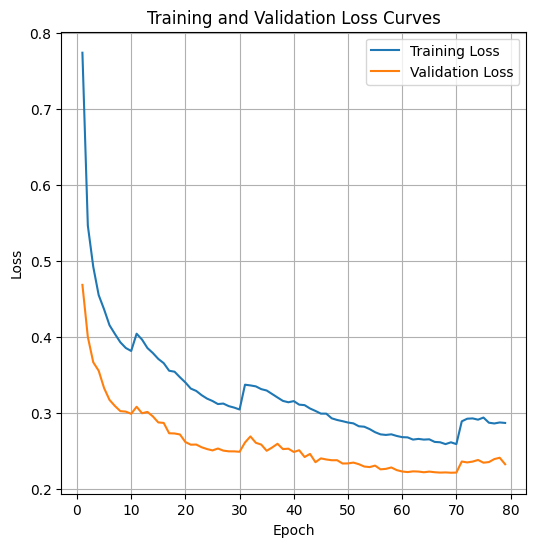

In [17]:

# 1. Loss Curves: Plot training and validation loss over epochs
epochs = range(1, len(train_loss_history) + 1)
plt.figure(figsize=(6, 6))
plt.plot(epochs, train_loss_history, label='Training Loss')
plt.plot(epochs, val_loss_history, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True)
plt.show()


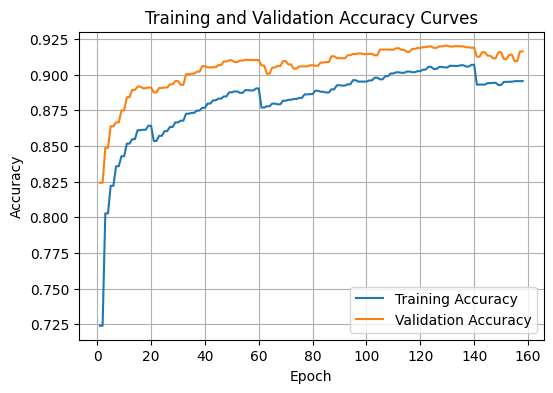

In [18]:

# 2. Accuracy Curves: Plot training and validation accuracy over epochs

plt.figure(figsize=(6, 4))
epochs = range(1, len(train_accuracy_history) + 1)
plt.plot(epochs, train_accuracy_history, label='Training Accuracy')
plt.plot(epochs, val_accuracy_history, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy Curves')
plt.legend()
plt.grid(True)
plt.show()


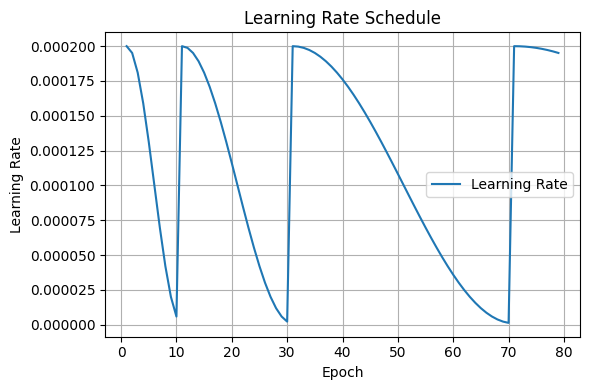

In [19]:

# 3. Learning Rate: Monitor learning rate changes
plt.figure(figsize=(6, 4))
epochs = range(1, len(learning_rates) + 1)
plt.plot(epochs, learning_rates, label='Learning Rate')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


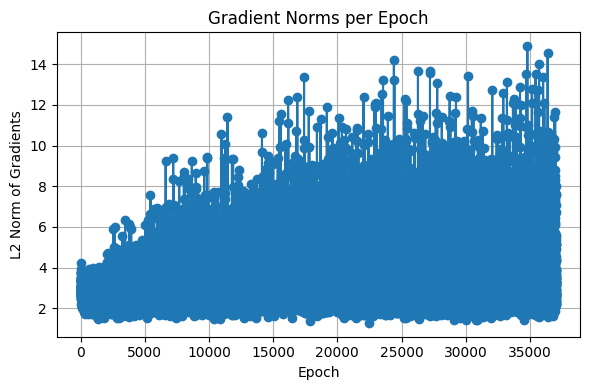

In [20]:

# 4. Gradient Norms: Visualize gradient magnitudes
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(gradient_norms) + 1), gradient_norms, marker='o')
plt.title("Gradient Norms per Epoch")
plt.xlabel("Epoch")
plt.ylabel("L2 Norm of Gradients")
plt.grid(True)
plt.tight_layout()
plt.show()


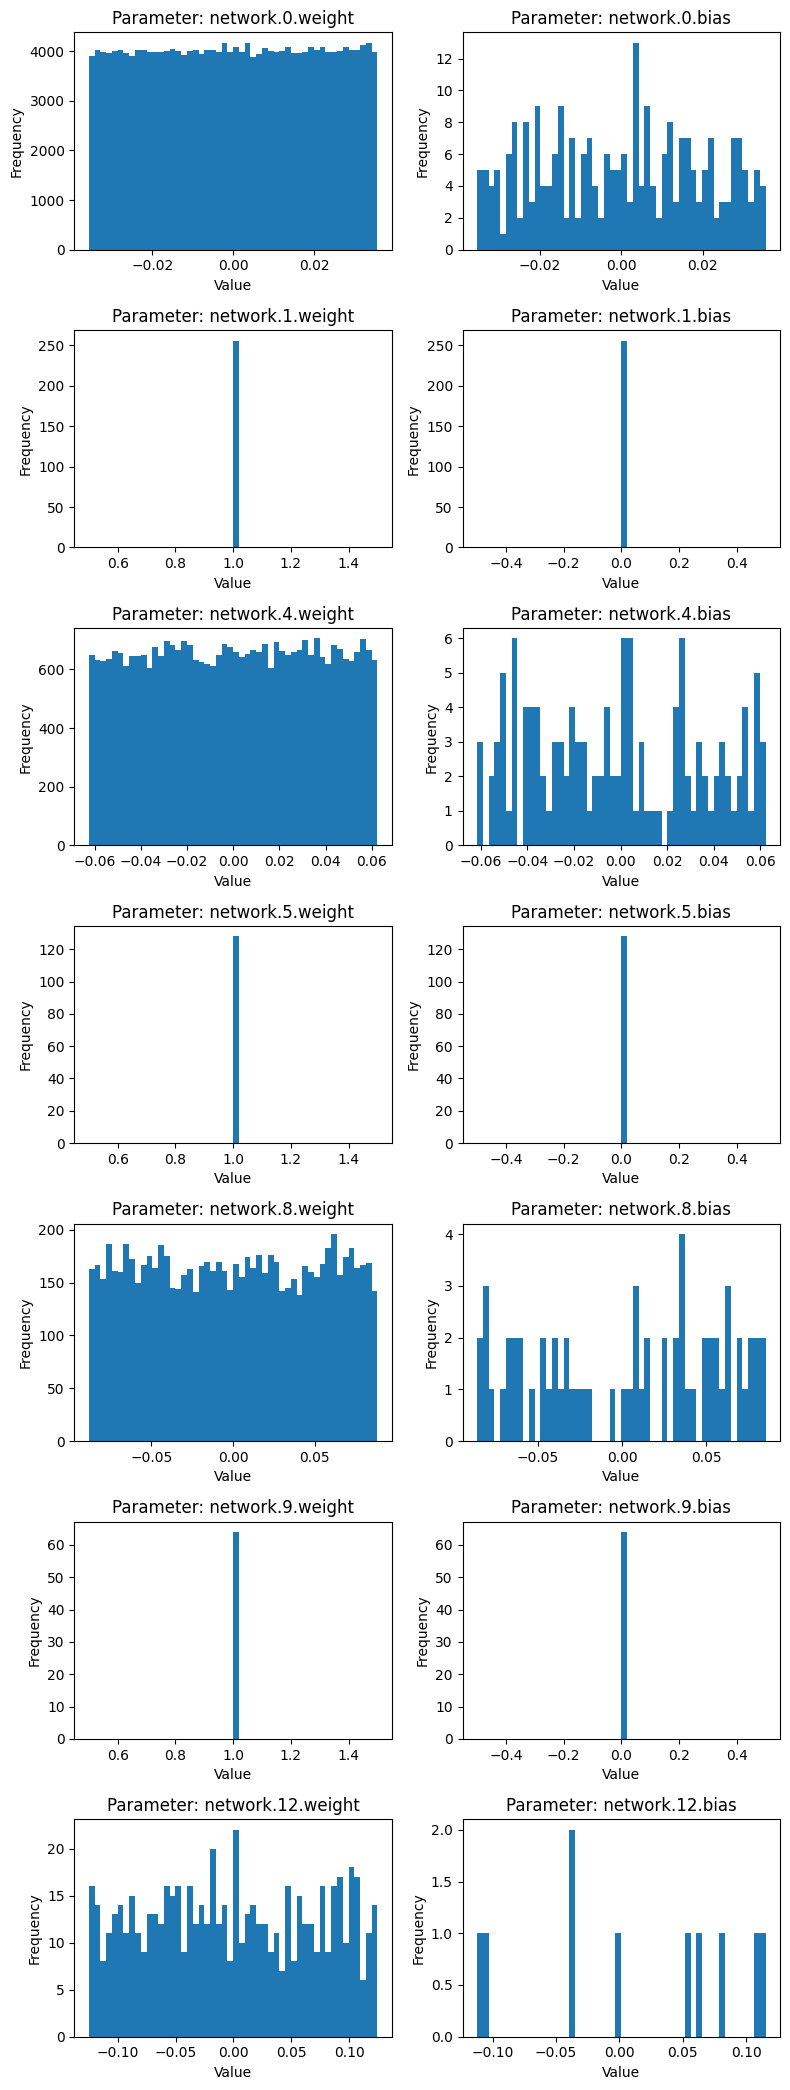

In [21]:

# 5. Parameter Distributions: Histograms of weight values (in subplots)
import math

# Collect all parameter names and values that require grad
param_list = [(name, param) for name, param in model.named_parameters() if param.requires_grad]
n_params = len(param_list)
n_cols = 2
n_rows = math.ceil(n_params / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten() if n_params > 1 else [axes]

for idx, (name, param) in enumerate(param_list):
    ax = axes[idx]
    ax.hist(param.detach().cpu().numpy().flatten(), bins=50)
    ax.set_title(f'Parameter: {name}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

# Hide any unused subplots
for idx in range(len(param_list), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


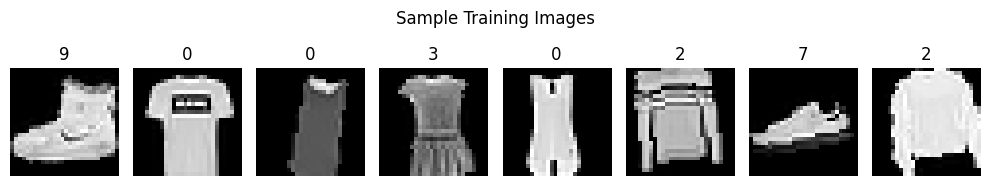

In [22]:

# --- Data Visualization Examples ---

# 6. Sample Images: Display training/test samples
dataiter = iter(train_dataloader)
images, labels = next(dataiter)
plt.figure(figsize=(10, 2))
for idx in range(8):
    plt.subplot(1, 8, idx+1)
    plt.imshow(images[idx].squeeze(), cmap='gray')
    plt.title(f"{labels[idx].item()}")
    plt.axis('off')
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()


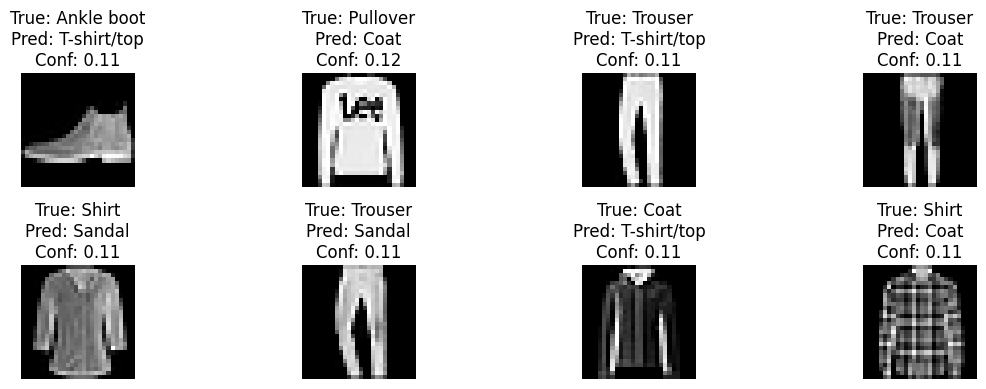

In [23]:

# 7. Predictions: Show model predictions with confidence
dataiter = iter(test_dataloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)
model.eval()
with torch.no_grad():
    outputs = model(images)
    probs = torch.softmax(outputs, dim=1)
    confs, preds = torch.max(probs, 1)
images, labels, preds, confs = images.cpu(), labels.cpu(), preds.cpu(), confs.cpu()
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
plt.figure(figsize=(12, 4))
for idx in range(8):
    plt.subplot(2, 4, idx+1)
    plt.imshow(images[idx].squeeze(), cmap='gray')
    plt.title(f"True: {class_names[labels[idx]]}\nPred: {class_names[preds[idx]]}\nConf: {confs[idx]:.2f}")
    plt.axis('off')
plt.tight_layout()
plt.show()


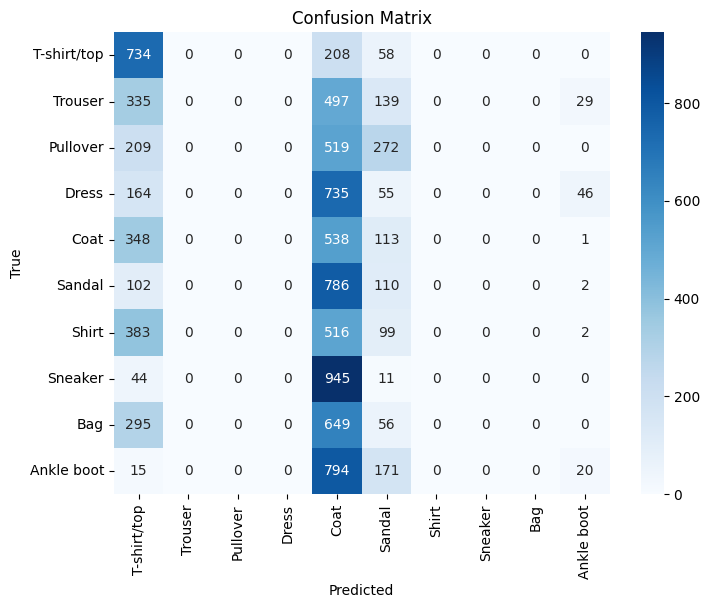

In [24]:

# 8. Confusion Matrix: Heatmap of prediction accuracy
from sklearn.metrics import confusion_matrix
import seaborn as sns
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [25]:

# 9. Feature Maps: Visualize learned representations (first conv layer)
def plot_feature_maps(model, image):
    model.eval()
    with torch.no_grad():
        x = image.unsqueeze(0).to(device)
        for name, layer in model.named_children():
            if isinstance(layer, torch.nn.Conv2d):
                x = layer(x)
                break
        feature_maps = x.cpu().squeeze()
    num_maps = feature_maps.shape[0]
    plt.figure(figsize=(12, 2))
    for i in range(min(num_maps, 8)):
        plt.subplot(1, 8, i+1)
        plt.imshow(feature_maps[i], cmap='viridis')
        plt.axis('off')
    plt.suptitle("First Conv Layer Feature Maps")
    plt.tight_layout()
    plt.show()
# Example usage:
# plot_feature_maps(model, images[0])

# 10. Attention Weights: Show model focus areas (if using attention)
# Example for a model with self-attention (pseudo-code)
# attention_weights = model.get_attention_weights(images[0:1].to(device))
# plt.imshow(attention_weights[0].cpu(), cmap='hot')
# plt.title("Attention Map")
# plt.colorbar()
# plt.show()


In [26]:

# --- Advanced Visualization ---

# 11. TensorBoard: Log scalars and images
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()
for epoch in range(len(train_loss_history)):
    writer.add_scalar('Loss/train', train_loss_history[epoch], epoch)
    writer.add_scalar('Loss/val', val_loss_history[epoch], epoch)
    writer.add_scalar('Accuracy/train', train_accuracy_history[epoch], epoch)
    writer.add_scalar('Accuracy/val', val_accuracy_history[epoch], epoch)
# To view: run `tensorboard --logdir=runs` in terminal

# 12. Weights & Biases: Log metrics (requires wandb)
# import wandb
# wandb.init(project="pytorch-visualization")
# for epoch in range(len(train_loss_history)):
#     wandb.log({
#         "train/loss": train_loss_history[epoch],
#         "val/loss": val_loss_history[epoch],
#         "train/acc": train_accuracy_history[epoch],
#         "val/acc": val_accuracy_history[epoch],
#     })

# 13. Matplotlib/Plotly: Custom plotting (see above for matplotlib)
# import plotly.express as px
# fig = px.line(x=epochs, y=train_loss_history, labels={'x':'Epoch', 'y':'Loss'}, title='Training Loss (Plotly)')
# fig.show()

# 14. Interactive Plots: Real-time training monitoring (pseudo-code)
# from IPython.display import clear_output
# for epoch in range(num_epochs):
#     train_one_epoch()
#     clear_output(wait=True)
#     plt.plot(...)
#     plt.show()


### 12. Advanced Topics and Tips

This section covers some advanced PyTorch features and best practices for efficient model development.

**Advanced PyTorch Features:**
- **Custom Datasets**: Create dataset classes for specific data
- **Data Augmentation**: Improve generalization with transforms
- **Mixed Precision Training**: Use FP16 for faster training
- **Distributed Training**: Scale training across multiple GPUs
- **Model Parallelism**: Split models across devices
- **Gradient Accumulation**: Handle large batch sizes

**Performance Optimization:**
- **Memory Management**: Efficient tensor operations
- **Profiling**: Identify bottlenecks with torch.profiler
- **JIT Compilation**: Optimize models with TorchScript
- **Quantization**: Reduce model size with INT8/FP16
- **Pruning**: Remove unnecessary connections
- **Knowledge Distillation**: Transfer knowledge to smaller models

**Debugging and Testing:**
- **Gradient Checking**: Verify gradient computations
- **Unit Tests**: Test individual components
- **Assertions**: Add runtime checks for tensor shapes
- **Logging**: Comprehensive logging for debugging

In [27]:
# Example 1: Custom Dataset
from torch.utils.data import Dataset

class CustomDataset(Dataset):
    def __init__(self, data, targets, transform=None):
        self.data = data
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        y = self.targets[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

# Example usage:
# custom_dataset = CustomDataset(data, targets, transform=ToTensor())
# custom_loader = DataLoader(custom_dataset, batch_size=32, shuffle=True)

# Example 2: Data Augmentation
from torchvision import transforms

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])
augmented_dataset = datasets.FashionMNIST(
    root="data", train=True, download=True, transform=transform
)

# Example 3: Mixed Precision Training
# (Requires a CUDA device)
if device.type == 'cuda':
    scaler = torch.cuda.amp.GradScaler()
    for data, target in train_dataloader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            output = model(data)
            loss = loss_fn(output, target)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

# Example 4: Distributed Training (Single-Node, Multi-GPU)
# (Requires torch.distributed and multiple GPUs)
# import torch.distributed as dist
# dist.init_process_group("nccl")
# model = torch.nn.parallel.DistributedDataParallel(model)

# Example 5: Model Parallelism
# (Split model layers across devices)
# class ModelParallelNet(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.part1 = nn.Linear(784, 512).to('cuda:0')
#         self.part2 = nn.Linear(512, 10).to('cuda:1')
#     def forward(self, x):
#         x = x.to('cuda:0')
#         x = self.part1(x)
#         x = x.to('cuda:1')
#         x = self.part2(x)
#         return x

# Example 6: Gradient Accumulation
accumulation_steps = 4
optimizer.zero_grad()
for i, (data, target) in enumerate(train_dataloader):
    data, target = data.to(device), target.to(device)
    output = model(data)
    loss = loss_fn(output, target) / accumulation_steps
    loss.backward()
    if (i + 1) % accumulation_steps == 0:
        optimizer.step()
        optimizer.zero_grad()

# Example 7: Profiling with torch.profiler
# with torch.profiler.profile(
#     schedule=torch.profiler.schedule(wait=1, warmup=1, active=3, repeat=2),
#     on_trace_ready=torch.profiler.tensorboard_trace_handler('./log'),
#     record_shapes=True,
#     with_stack=True
# ) as prof:
#     for step, (data, target) in enumerate(train_dataloader):
#         output = model(data.to(device))
#         loss = loss_fn(output, target.to(device))
#         loss.backward()
#         optimizer.step()
#         optimizer.zero_grad()
#         prof.step()

# Example 8: JIT Compilation
# scripted_model = torch.jit.script(model)
# torch.jit.save(scripted_model, "model_scripted.pt")

# Example 9: Quantization (Post-training static quantization)
# from torch.quantization import quantize_dynamic
# quantized_model = quantize_dynamic(model, {nn.Linear}, dtype=torch.qint8)

# Example 10: Pruning
# from torch.nn.utils import prune
# prune.l1_unstructured(model.linear_relu_stack[0], name="weight", amount=0.2)

# Example 11: Gradient Checking
# x = torch.randn(2, 2, requires_grad=True, dtype=torch.double)
# def func(input):
#     return model(input)
# torch.autograd.gradcheck(func, (x,))

# Example 12: Assertions and Logging
# assert data.shape[1:] == (1, 28, 28), "Input shape mismatch"
# import logging
# logging.basicConfig(level=logging.INFO)
# logging.info("Training started")


### 13. References and Further Reading

For more information, check the official [PyTorch documentation](https://pytorch.org/docs/stable/index.html) and other recommended resources.

**Official Resources:**
- **PyTorch Tutorials**: [pytorch.org/tutorials](https://pytorch.org/tutorials/)
- **PyTorch Examples**: [github.com/pytorch/examples](https://github.com/pytorch/examples)
- **PyTorch Forums**: [discuss.pytorch.org](https://discuss.pytorch.org/)
- **PyTorch GitHub**: [github.com/pytorch/pytorch](https://github.com/pytorch/pytorch)
- **PyTorch Blog**: [pytorch.org/blog](https://pytorch.org/blog/)

**Books and Courses:**
- **"Deep Learning with PyTorch"** by Eli Stevens, Luca Antiga, and Thomas Viehmann
- **"Programming PyTorch for Deep Learning"** by Ian Pointer
- **"Hands-On Machine Learning"** by Aurélien Géron (PyTorch implementations)
- **CS231n Stanford**: Computer Vision course with PyTorch
- **Fast.ai**: Practical Deep Learning course
- **Coursera**: Deep Learning Specialization

**Community Resources:**
- **PyTorch Lightning**: High-level training framework
- **Hugging Face**: Transformers and model hub
- **Papers with Code**: Research implementations
- **Kaggle**: Competitions and datasets
- **GitHub**: Open-source PyTorch projects
- **Stack Overflow**: Community Q&A

In [28]:
import torch
from torch import nn
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

def get_device():
    """
    Automatically detects and returns the best available device for PyTorch.
    Prioritizes CUDA (GPU), then MPS (Apple Silicon), and finally defaults to CPU.
    """
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using CUDA device: {torch.cuda.get_device_name(0)}")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("Using MPS device (Apple Silicon GPU)")
    else:
        device = torch.device("cpu")
        print("Using CPU device")
    return device

# Get the device
device = get_device()

Using MPS device (Apple Silicon GPU)
